In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────
customers = pd.read_csv("customers.csv")
products  = pd.read_csv("products.csv")
sales     = pd.read_csv("sales.csv")

# ── Apply Cleaning ─────────────────────────────────────────
sales['Order_Date']   = pd.to_datetime(sales['Order_Date'])
sales['Delivery_Date']= pd.to_datetime(sales['Delivery_Date'])
sales['Coupon_Code']  = sales['Coupon_Code'].fillna('No Coupon')
sales['Has_Review']   = sales['Rating'].notna().astype(int)
sales                 = sales[sales['Total_Amount'] >= 0]

# ── Shared Plot Style ──────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     15,
    'figure.dpi':        150,
})

print("✅ Setup complete.")
print(f"   Customers : {customers.shape}")
print(f"   Products  : {products.shape}")
print(f"   Sales     : {sales.shape}")

✅ Setup complete.
   Customers : (40000, 15)
   Products  : (2000, 12)
   Sales     : (249995, 22)


In [2]:
# ── DATA PREPARATION ───────────────────────────────────────

# Step 1: Filter only Delivered and Cancelled orders
df = sales[sales['Order_Status'].isin(['Delivered', 'Cancelled'])].copy()
print(f"Filtered rows: {len(df):,}")
print(df['Order_Status'].value_counts())

# Step 2: Create binary target variable
# Delivered = 1, Cancelled = 0
df['Target'] = (df['Order_Status'] == 'Delivered').astype(int)

# Step 3: Add delivery days as a feature
df['Delivery_Days'] = (df['Delivery_Date'] - df['Order_Date']).dt.days

# Step 4: Add coupon flag
df['Coupon_Used'] = (df['Coupon_Code'] != 'No Coupon').astype(int)

# Step 5: Select features
features = [
    'Quantity',
    'Unit_Price',
    'Order_Value',
    'Shipping_Cost',
    'Coupon_Discount',
    'Total_Amount',
    'Customer_Age',
    'Has_Review',
    'Coupon_Used',
    'Delivery_Days',
    'Payment_Mode',
    'State',
    'Customer_Age_Group',
]

df_model = df[features + ['Target']].copy()

# Step 6: Encode categorical columns
le = LabelEncoder()
for col in ['Payment_Mode', 'State', 'Customer_Age_Group']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Step 7: Drop any nulls
df_model.dropna(inplace=True)
print(f"\nFinal model dataset shape: {df_model.shape}")
print(f"\nTarget distribution:")
print(df_model['Target'].value_counts())
print(f"\nClass balance:")
print(df_model['Target'].value_counts(normalize=True).mul(100).round(2))

# Step 8: Split features and target
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# Step 9: Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 10: Scale numerical features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")
print("\n✅ Data preparation complete.")

Filtered rows: 212,641
Order_Status
Delivered    200135
Cancelled     12506
Name: count, dtype: int64

Final model dataset shape: (212641, 14)

Target distribution:
Target
1    200135
0     12506
Name: count, dtype: int64

Class balance:
Target
1    94.12
0     5.88
Name: proportion, dtype: float64

Training set : (170112, 13)
Testing set  : (42529, 13)

✅ Data preparation complete.


In [3]:
# ── Fix Class Imbalance with SMOTE ─────────────────────────
# Install if needed
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ SMOTE applied.")
print(f"\nBefore SMOTE:")
print(f"   Class 0 (Cancelled) : {sum(y_train == 0):,}")
print(f"   Class 1 (Delivered) : {sum(y_train == 1):,}")

print(f"\nAfter SMOTE:")
print(f"   Class 0 (Cancelled) : {sum(y_train_bal == 0):,}")
print(f"   Class 1 (Delivered) : {sum(y_train_bal == 1):,}")

print(f"\nNew Training set shape: {X_train_bal.shape}")

✅ SMOTE applied.

Before SMOTE:
   Class 0 (Cancelled) : 10,005
   Class 1 (Delivered) : 160,107

After SMOTE:
   Class 0 (Cancelled) : 160,107
   Class 1 (Delivered) : 160,107

New Training set shape: (320214, 13)


MODEL 1: LOGISTIC REGRESSION

Accuracy  : 0.6263  (62.63%)
Precision : 1.0000
Recall    : 0.6029
F1 Score  : 0.7523

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.14      1.00      0.24      2501
   Delivered       1.00      0.60      0.75     40028

    accuracy                           0.63     42529
   macro avg       0.57      0.80      0.50     42529
weighted avg       0.95      0.63      0.72     42529

AUC Score : 0.8034


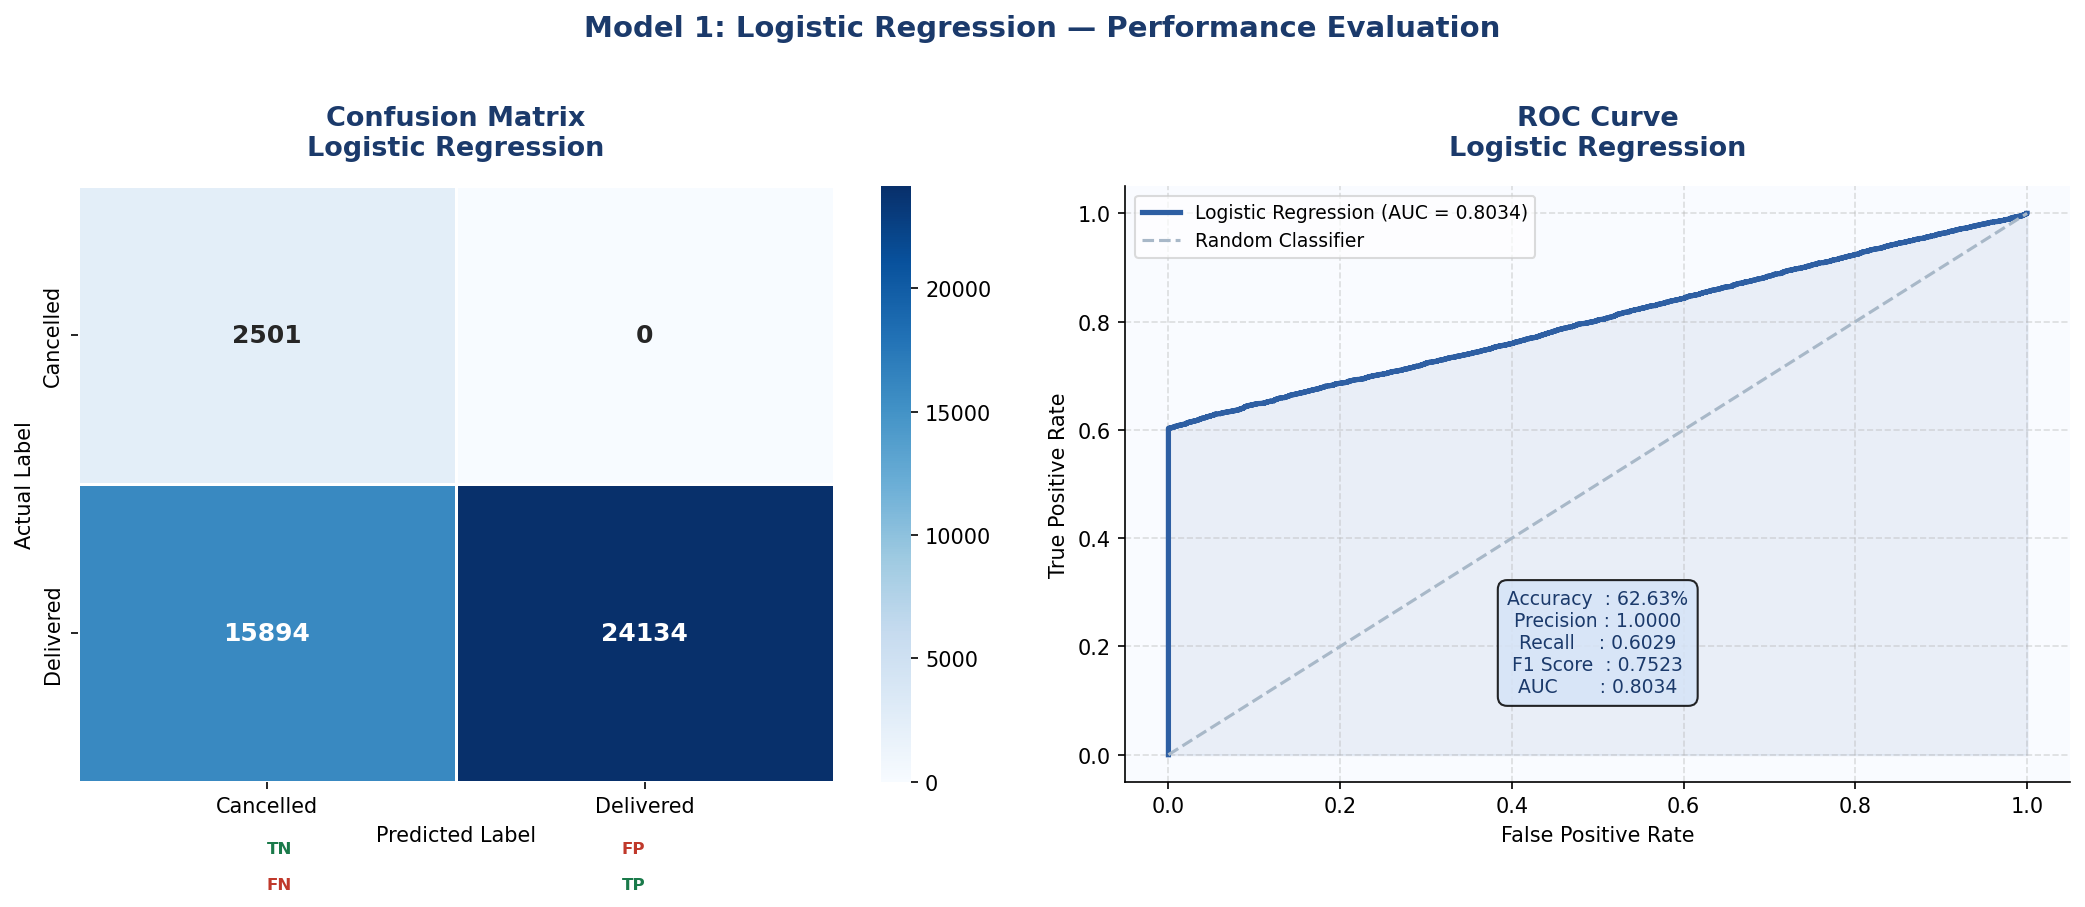


✅ Model 1 visualization saved.


In [4]:
# ── MODEL 1: LOGISTIC REGRESSION ──────────────────────────

print("=" * 55)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 55)

# ── Train ──────────────────────────────────────────────────
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)

# ── Predict ────────────────────────────────────────────────
lr_pred      = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]

# ── Metrics ────────────────────────────────────────────────
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print(f"\nAccuracy  : {lr_acc:.4f}  ({lr_acc*100:.2f}%)")
print(f"Precision : {lr_prec:.4f}")
print(f"Recall    : {lr_rec:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Cancelled', 'Delivered']))

# ── Confusion Matrix ───────────────────────────────────────
lr_cm = confusion_matrix(y_test, lr_pred)

# ── ROC Curve ──────────────────────────────────────────────
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_prob)
lr_auc            = auc(lr_fpr, lr_tpr)
print(f"AUC Score : {lr_auc:.4f}")

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Confusion Matrix
ax1 = axes[0]
sns.heatmap(lr_cm, annot=True, fmt='d',
            cmap='Blues', linewidths=0.5,
            xticklabels=['Cancelled', 'Delivered'],
            yticklabels=['Cancelled', 'Delivered'],
            annot_kws={'size': 12, 'weight': 'bold'},
            ax=ax1)
ax1.set_title('Confusion Matrix\nLogistic Regression',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Predicted Label', fontsize=10)
ax1.set_ylabel('Actual Label', fontsize=10)

# Annotate TP, TN, FP, FN
ax1.text(0.25, -0.12, 'TN', transform=ax1.transAxes,
         fontsize=8, color='#1A7A4A', fontweight='bold')
ax1.text(0.72, -0.12, 'FP', transform=ax1.transAxes,
         fontsize=8, color='#C0392B', fontweight='bold')
ax1.text(0.25, -0.18, 'FN', transform=ax1.transAxes,
         fontsize=8, color='#C0392B', fontweight='bold')
ax1.text(0.72, -0.18, 'TP', transform=ax1.transAxes,
         fontsize=8, color='#1A7A4A', fontweight='bold')

# Right — ROC Curve
ax2 = axes[1]
ax2.plot(lr_fpr, lr_tpr, color='#2E5FA3', linewidth=2.5,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='#A8B8C8',
         linestyle='--', linewidth=1.5, label='Random Classifier')
ax2.fill_between(lr_fpr, lr_tpr, alpha=0.08, color='#2E5FA3')
ax2.set_title('ROC Curve\nLogistic Regression',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.7)
ax2.grid(linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

# Summary box
ax2.text(0.5, 0.15,
         f'Accuracy  : {lr_acc*100:.2f}%\n'
         f'Precision : {lr_prec:.4f}\n'
         f'Recall    : {lr_rec:.4f}\n'
         f'F1 Score  : {lr_f1:.4f}\n'
         f'AUC       : {lr_auc:.4f}',
         transform=ax2.transAxes, ha='center',
         fontsize=9, color='#1B3A6B',
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='#D6E4F7', alpha=0.85))

fig.suptitle('Model 1: Logistic Regression — Performance Evaluation',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('model1_logistic_regression.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Model 1 visualization saved.")

MODEL 2: DECISION TREE

Accuracy  : 0.6530  (65.30%)
Precision : 0.9919
Recall    : 0.6366
F1 Score  : 0.7755

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.14      0.92      0.24      2501
   Delivered       0.99      0.64      0.78     40028

    accuracy                           0.65     42529
   macro avg       0.56      0.78      0.51     42529
weighted avg       0.94      0.65      0.74     42529

AUC Score : 0.8010

Top 5 Important Features:
      Feature  Importance
   Has_Review    0.890961
        State    0.080747
 Customer_Age    0.018224
Delivery_Days    0.003321
   Unit_Price    0.002692


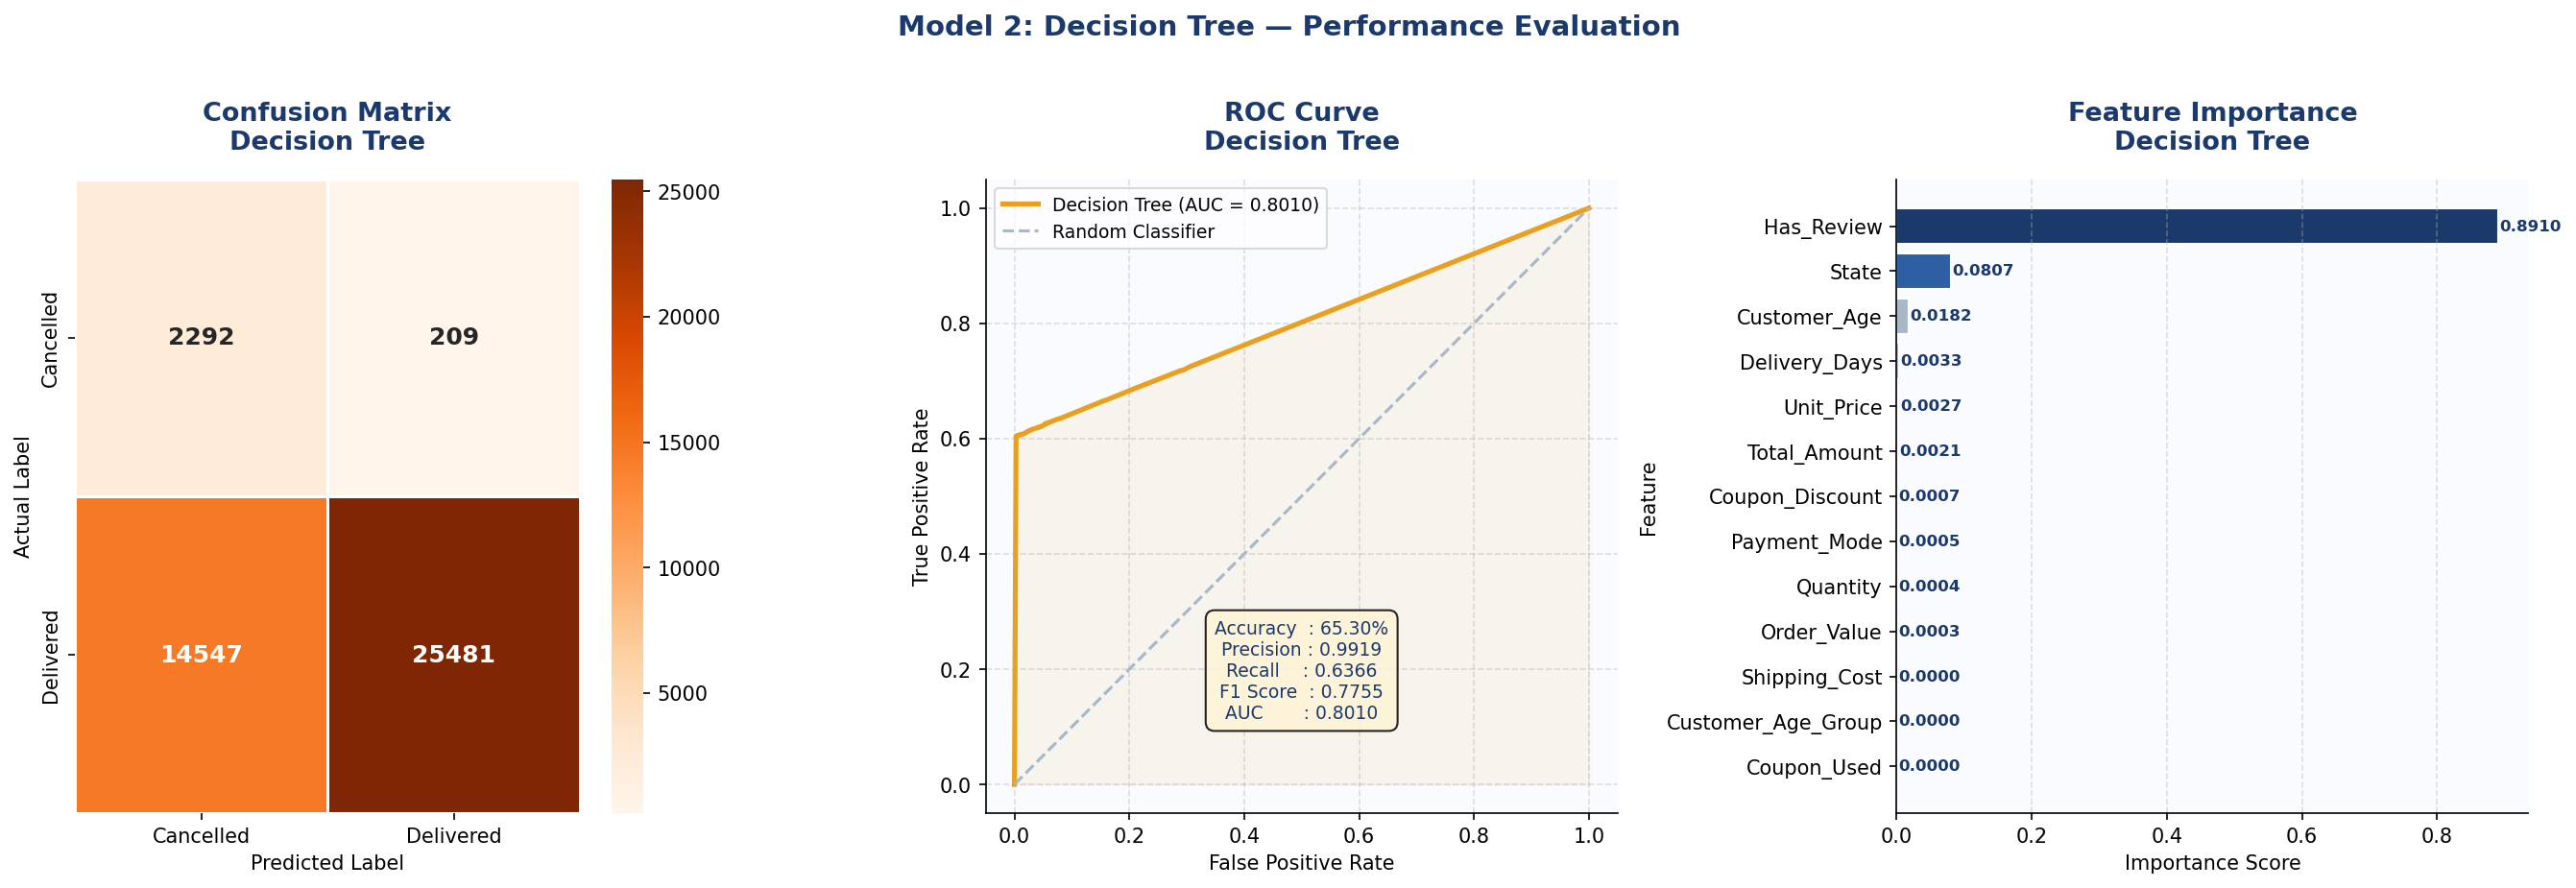


✅ Model 2 visualization saved.


In [5]:
# ── MODEL 2: DECISION TREE ─────────────────────────────────

print("=" * 55)
print("MODEL 2: DECISION TREE")
print("=" * 55)

# ── Train ──────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced'
)
dt_model.fit(X_train_bal, y_train_bal)

# ── Predict ────────────────────────────────────────────────
dt_pred      = dt_model.predict(X_test)
dt_pred_prob = dt_model.predict_proba(X_test)[:, 1]

# ── Metrics ────────────────────────────────────────────────
dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec  = recall_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)

print(f"\nAccuracy  : {dt_acc:.4f}  ({dt_acc*100:.2f}%)")
print(f"Precision : {dt_prec:.4f}")
print(f"Recall    : {dt_rec:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Cancelled', 'Delivered']))

# ── Confusion Matrix ───────────────────────────────────────
dt_cm = confusion_matrix(y_test, dt_pred)

# ── ROC Curve ──────────────────────────────────────────────
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_pred_prob)
dt_auc            = auc(dt_fpr, dt_tpr)
print(f"AUC Score : {dt_auc:.4f}")

# ── Feature Importance ─────────────────────────────────────
feature_names = X.columns.tolist()
importances   = dt_model.feature_importances_
feat_imp_df   = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\nTop 5 Important Features:")
print(feat_imp_df.head(5).to_string(index=False))

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left — Confusion Matrix
ax1 = axes[0]
sns.heatmap(dt_cm, annot=True, fmt='d',
            cmap='Oranges', linewidths=0.5,
            xticklabels=['Cancelled', 'Delivered'],
            yticklabels=['Cancelled', 'Delivered'],
            annot_kws={'size': 12, 'weight': 'bold'},
            ax=ax1)
ax1.set_title('Confusion Matrix\nDecision Tree',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Predicted Label', fontsize=10)
ax1.set_ylabel('Actual Label', fontsize=10)

# Middle — ROC Curve
ax2 = axes[1]
ax2.plot(dt_fpr, dt_tpr, color='#E8A020', linewidth=2.5,
         label=f'Decision Tree (AUC = {dt_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='#A8B8C8',
         linestyle='--', linewidth=1.5, label='Random Classifier')
ax2.fill_between(dt_fpr, dt_tpr, alpha=0.08, color='#E8A020')
ax2.set_title('ROC Curve\nDecision Tree',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.7)
ax2.grid(linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

ax2.text(0.5, 0.15,
         f'Accuracy  : {dt_acc*100:.2f}%\n'
         f'Precision : {dt_prec:.4f}\n'
         f'Recall    : {dt_rec:.4f}\n'
         f'F1 Score  : {dt_f1:.4f}\n'
         f'AUC       : {dt_auc:.4f}',
         transform=ax2.transAxes, ha='center',
         fontsize=9, color='#1B3A6B',
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='#FFF3D6', alpha=0.85))

# Right — Feature Importance
ax3 = axes[2]
colors_feat = ['#1B3A6B' if i == 0 else '#2E5FA3' if i == 1
               else '#A8B8C8' for i in range(len(feat_imp_df))]
ax3.barh(feat_imp_df['Feature'][::-1],
         feat_imp_df['Importance'][::-1],
         color=colors_feat[::-1], edgecolor='white')

for i, (val, name) in enumerate(zip(
        feat_imp_df['Importance'][::-1],
        feat_imp_df['Feature'][::-1])):
    ax3.text(val + 0.002, i,
             f'{val:.4f}',
             va='center', fontsize=8,
             color='#1B3A6B', fontweight='bold')

ax3.set_title('Feature Importance\nDecision Tree',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax3.set_xlabel('Importance Score', fontsize=10)
ax3.set_ylabel('Feature', fontsize=10)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
ax3.set_facecolor('#F9FBFF')

fig.suptitle('Model 2: Decision Tree — Performance Evaluation',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('model2_decision_tree.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Model 2 visualization saved.")

MODEL 3: RANDOM FOREST
Training complete.

Accuracy  : 0.6555  (65.55%)
Precision : 0.9912
Recall    : 0.6397
F1 Score  : 0.7775

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.14      0.91      0.24      2501
   Delivered       0.99      0.64      0.78     40028

    accuracy                           0.66     42529
   macro avg       0.56      0.77      0.51     42529
weighted avg       0.94      0.66      0.75     42529

AUC Score : 0.8006

Top 5 Important Features:
        Feature  Importance
     Has_Review    0.860128
          State    0.038844
   Customer_Age    0.026662
  Delivery_Days    0.022752
Coupon_Discount    0.010608


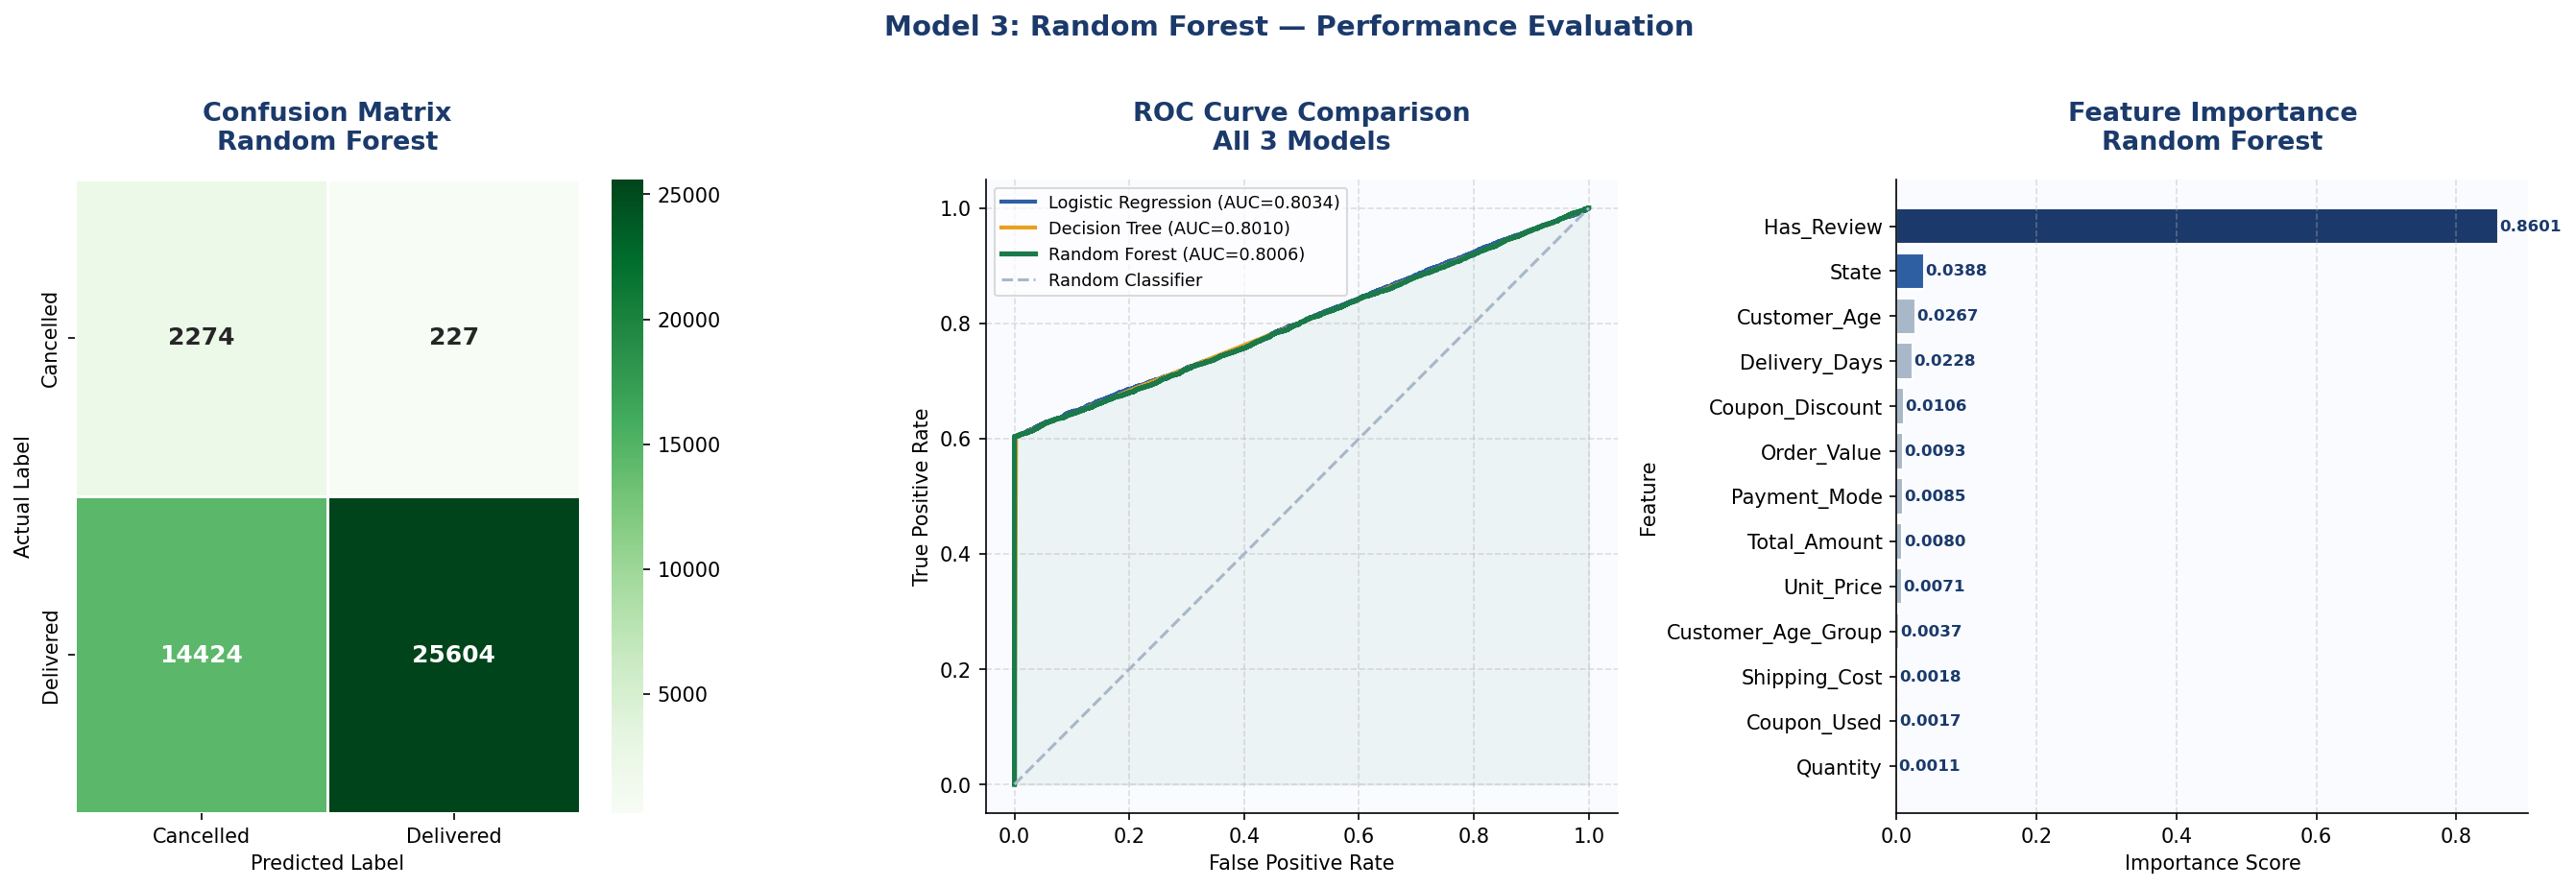


✅ Model 3 visualization saved.


In [6]:
# ── MODEL 3: RANDOM FOREST ─────────────────────────────────

print("=" * 55)
print("MODEL 3: RANDOM FOREST")
print("=" * 55)

# ── Train ──────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)
print("Training complete.")

# ── Predict ────────────────────────────────────────────────
rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# ── Metrics ────────────────────────────────────────────────
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print(f"\nAccuracy  : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print(f"Precision : {rf_prec:.4f}")
print(f"Recall    : {rf_rec:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Cancelled', 'Delivered']))

# ── Confusion Matrix ───────────────────────────────────────
rf_cm = confusion_matrix(y_test, rf_pred)

# ── ROC Curve ──────────────────────────────────────────────
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_prob)
rf_auc            = auc(rf_fpr, rf_tpr)
print(f"AUC Score : {rf_auc:.4f}")

# ── Feature Importance ─────────────────────────────────────
feature_names  = X.columns.tolist()
rf_importances = rf_model.feature_importances_
rf_feat_df     = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

print(f"\nTop 5 Important Features:")
print(rf_feat_df.head(5).to_string(index=False))

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left — Confusion Matrix
ax1 = axes[0]
sns.heatmap(rf_cm, annot=True, fmt='d',
            cmap='Greens', linewidths=0.5,
            xticklabels=['Cancelled', 'Delivered'],
            yticklabels=['Cancelled', 'Delivered'],
            annot_kws={'size': 12, 'weight': 'bold'},
            ax=ax1)
ax1.set_title('Confusion Matrix\nRandom Forest',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Predicted Label', fontsize=10)
ax1.set_ylabel('Actual Label', fontsize=10)

# Middle — ROC Curve (all 3 models together)
ax2 = axes[1]
ax2.plot(lr_fpr, lr_tpr, color='#2E5FA3', linewidth=2,
         label=f'Logistic Regression (AUC={lr_auc:.4f})')
ax2.plot(dt_fpr, dt_tpr, color='#E8A020', linewidth=2,
         label=f'Decision Tree (AUC={dt_auc:.4f})')
ax2.plot(rf_fpr, rf_tpr, color='#1A7A4A', linewidth=2.5,
         label=f'Random Forest (AUC={rf_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='#A8B8C8',
         linestyle='--', linewidth=1.5,
         label='Random Classifier')
ax2.fill_between(rf_fpr, rf_tpr, alpha=0.06, color='#1A7A4A')
ax2.set_title('ROC Curve Comparison\nAll 3 Models',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.legend(fontsize=8.5, framealpha=0.7)
ax2.grid(linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

# Right — Feature Importance
ax3 = axes[2]
colors_feat = ['#1B3A6B' if i == 0 else '#2E5FA3' if i == 1
               else '#A8B8C8' for i in range(len(rf_feat_df))]
ax3.barh(rf_feat_df['Feature'][::-1],
         rf_feat_df['Importance'][::-1],
         color=colors_feat[::-1], edgecolor='white')

for i, val in enumerate(rf_feat_df['Importance'][::-1]):
    ax3.text(val + 0.002, i,
             f'{val:.4f}',
             va='center', fontsize=8,
             color='#1B3A6B', fontweight='bold')

ax3.set_title('Feature Importance\nRandom Forest',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax3.set_xlabel('Importance Score', fontsize=10)
ax3.set_ylabel('Feature', fontsize=10)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
ax3.set_facecolor('#F9FBFF')

fig.suptitle('Model 3: Random Forest — Performance Evaluation',
             fontsize=14, fontweight='bold', color='#1B3A6B', y=1.02)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('model3_random_forest.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Model 3 visualization saved.")

In [7]:
# ── LEAKAGE-SAFE DATA PREPARATION ──────────────────────────

print("=" * 60)
print("LEAKAGE-SAFE MODEL PREPARATION")
print("=" * 60)

# Keep only Delivered and Cancelled orders
df_safe = sales[sales['Order_Status'].isin(
    ['Delivered', 'Cancelled']
)].copy()

# Create target
# Delivered = 1
# Cancelled = 0
df_safe['Target'] = (
    df_safe['Order_Status'] == 'Delivered'
).astype(int)

# Create coupon flag
df_safe['Coupon_Used'] = (
    df_safe['Coupon_Code'] != 'No Coupon'
).astype(int)

# IMPORTANT:
# Has_Review and Delivery_Days are intentionally removed
# because they may contain information unavailable at order time.

safe_features = [
    'Quantity',
    'Unit_Price',
    'Order_Value',
    'Shipping_Cost',
    'Coupon_Discount',
    'Total_Amount',
    'Customer_Age',
    'Coupon_Used',
    'Payment_Mode',
    'State',
    'Customer_Age_Group'
]

df_safe_model = df_safe[
    safe_features + ['Target']
].copy()

# Encode categorical features
safe_label_encoders = {}

for col in ['Payment_Mode', 'State', 'Customer_Age_Group']:
    encoder = LabelEncoder()
    df_safe_model[col] = encoder.fit_transform(
        df_safe_model[col].astype(str)
    )
    safe_label_encoders[col] = encoder

# Remove missing values
df_safe_model.dropna(inplace=True)

print(f"\nFinal leakage-safe dataset shape: {df_safe_model.shape}")

print("\nTarget distribution:")
print(df_safe_model['Target'].value_counts())

print("\nClass balance:")
print(
    df_safe_model['Target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Separate features and target
X_safe = df_safe_model.drop('Target', axis=1)
y_safe = df_safe_model['Target']

# Train/Test split
X_safe_train, X_safe_test, y_safe_train, y_safe_test = train_test_split(
    X_safe,
    y_safe,
    test_size=0.2,
    random_state=42,
    stratify=y_safe
)

# Scale features
safe_scaler = StandardScaler()

X_safe_train = safe_scaler.fit_transform(X_safe_train)
X_safe_test = safe_scaler.transform(X_safe_test)

print(f"\nTraining set : {X_safe_train.shape}")
print(f"Testing set  : {X_safe_test.shape}")

print("\n✅ Leakage-safe data preparation complete.")

LEAKAGE-SAFE MODEL PREPARATION

Final leakage-safe dataset shape: (212641, 12)

Target distribution:
Target
1    200135
0     12506
Name: count, dtype: int64

Class balance:
Target
1    94.12
0     5.88
Name: proportion, dtype: float64

Training set : (170112, 11)
Testing set  : (42529, 11)

✅ Leakage-safe data preparation complete.


In [8]:
# ── SMOTE FOR LEAKAGE-SAFE MODEL ───────────────────────────

smote_safe = SMOTE(random_state=42)

X_safe_train_bal, y_safe_train_bal = smote_safe.fit_resample(
    X_safe_train,
    y_safe_train
)

print("=" * 60)
print("SMOTE — LEAKAGE-SAFE TRAINING DATA")
print("=" * 60)

print("\nBefore SMOTE:")
print(
    f"   Class 0 (Cancelled) : {sum(y_safe_train == 0):,}"
)
print(
    f"   Class 1 (Delivered) : {sum(y_safe_train == 1):,}"
)

print("\nAfter SMOTE:")
print(
    f"   Class 0 (Cancelled) : {sum(y_safe_train_bal == 0):,}"
)
print(
    f"   Class 1 (Delivered) : {sum(y_safe_train_bal == 1):,}"
)

print(
    f"\nNew Training set shape: {X_safe_train_bal.shape}"
)

print("\n✅ Leakage-safe SMOTE complete.")

SMOTE — LEAKAGE-SAFE TRAINING DATA

Before SMOTE:
   Class 0 (Cancelled) : 10,005
   Class 1 (Delivered) : 160,107

After SMOTE:
   Class 0 (Cancelled) : 160,107
   Class 1 (Delivered) : 160,107

New Training set shape: (320214, 11)

✅ Leakage-safe SMOTE complete.


In [9]:
# ── LEAKAGE-SAFE MODEL 1: LOGISTIC REGRESSION ──────────────

print("=" * 60)
print("LEAKAGE-SAFE MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

# Train
lr_safe_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_safe_model.fit(
    X_safe_train_bal,
    y_safe_train_bal
)

# Predict
lr_safe_pred = lr_safe_model.predict(X_safe_test)
lr_safe_pred_prob = lr_safe_model.predict_proba(
    X_safe_test
)[:, 1]

# Metrics
lr_safe_acc = accuracy_score(
    y_safe_test, lr_safe_pred
)

lr_safe_prec = precision_score(
    y_safe_test, lr_safe_pred
)

lr_safe_rec = recall_score(
    y_safe_test, lr_safe_pred
)

lr_safe_f1 = f1_score(
    y_safe_test, lr_safe_pred
)

print(f"\nAccuracy  : {lr_safe_acc:.4f} ({lr_safe_acc*100:.2f}%)")
print(f"Precision : {lr_safe_prec:.4f}")
print(f"Recall    : {lr_safe_rec:.4f}")
print(f"F1 Score  : {lr_safe_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_safe_test,
        lr_safe_pred,
        target_names=['Cancelled', 'Delivered']
    )
)

# Confusion matrix
lr_safe_cm = confusion_matrix(
    y_safe_test,
    lr_safe_pred
)

# ROC / AUC
lr_safe_fpr, lr_safe_tpr, _ = roc_curve(
    y_safe_test,
    lr_safe_pred_prob
)

lr_safe_auc = auc(
    lr_safe_fpr,
    lr_safe_tpr
)

print(f"AUC Score : {lr_safe_auc:.4f}")

print("\n✅ Leakage-safe Logistic Regression complete.")

LEAKAGE-SAFE MODEL 1: LOGISTIC REGRESSION

Accuracy  : 0.4780 (47.80%)
Precision : 0.9410
Recall    : 0.4752
F1 Score  : 0.6315

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.06      0.52      0.11      2501
   Delivered       0.94      0.48      0.63     40028

    accuracy                           0.48     42529
   macro avg       0.50      0.50      0.37     42529
weighted avg       0.89      0.48      0.60     42529

AUC Score : 0.5014

✅ Leakage-safe Logistic Regression complete.


In [10]:
# ── LEAKAGE-SAFE MODEL 2: DECISION TREE ────────────────────

print("=" * 60)
print("LEAKAGE-SAFE MODEL 2: DECISION TREE")
print("=" * 60)

# Train
dt_safe_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced'
)

dt_safe_model.fit(
    X_safe_train_bal,
    y_safe_train_bal
)

# Predict
dt_safe_pred = dt_safe_model.predict(X_safe_test)
dt_safe_pred_prob = dt_safe_model.predict_proba(
    X_safe_test
)[:, 1]

# Metrics
dt_safe_acc = accuracy_score(
    y_safe_test, dt_safe_pred
)

dt_safe_prec = precision_score(
    y_safe_test, dt_safe_pred
)

dt_safe_rec = recall_score(
    y_safe_test, dt_safe_pred
)

dt_safe_f1 = f1_score(
    y_safe_test, dt_safe_pred
)

print(f"\nAccuracy  : {dt_safe_acc:.4f} ({dt_safe_acc*100:.2f}%)")
print(f"Precision : {dt_safe_prec:.4f}")
print(f"Recall    : {dt_safe_rec:.4f}")
print(f"F1 Score  : {dt_safe_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_safe_test,
        dt_safe_pred,
        target_names=['Cancelled', 'Delivered']
    )
)

# Confusion matrix
dt_safe_cm = confusion_matrix(
    y_safe_test,
    dt_safe_pred
)

# ROC / AUC
dt_safe_fpr, dt_safe_tpr, _ = roc_curve(
    y_safe_test,
    dt_safe_pred_prob
)

dt_safe_auc = auc(
    dt_safe_fpr,
    dt_safe_tpr
)

print(f"AUC Score : {dt_safe_auc:.4f}")

# Feature importance
safe_feature_names = X_safe.columns.tolist()

dt_safe_importances = dt_safe_model.feature_importances_

dt_safe_feat_df = pd.DataFrame({
    'Feature': safe_feature_names,
    'Importance': dt_safe_importances
}).sort_values(
    'Importance',
    ascending=False
)

print("\nTop 5 Important Features:")
print(
    dt_safe_feat_df.head(5).to_string(index=False)
)

print("\n✅ Leakage-safe Decision Tree complete.")

LEAKAGE-SAFE MODEL 2: DECISION TREE

Accuracy  : 0.9395 (93.95%)
Precision : 0.9412
Recall    : 0.9980
F1 Score  : 0.9688

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.08      0.00      0.01      2501
   Delivered       0.94      1.00      0.97     40028

    accuracy                           0.94     42529
   macro avg       0.51      0.50      0.49     42529
weighted avg       0.89      0.94      0.91     42529

AUC Score : 0.4974

Top 5 Important Features:
     Feature  Importance
Customer_Age    0.916924
  Unit_Price    0.027377
       State    0.023199
Total_Amount    0.016917
Payment_Mode    0.007370

✅ Leakage-safe Decision Tree complete.


In [11]:
# ── LEAKAGE-SAFE MODEL 3: RANDOM FOREST ────────────────────

print("=" * 60)
print("LEAKAGE-SAFE MODEL 3: RANDOM FOREST")
print("=" * 60)

# Train
rf_safe_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_safe_model.fit(
    X_safe_train_bal,
    y_safe_train_bal
)

print("Training complete.")

# Predict
rf_safe_pred = rf_safe_model.predict(X_safe_test)

rf_safe_pred_prob = rf_safe_model.predict_proba(
    X_safe_test
)[:, 1]

# Metrics
rf_safe_acc = accuracy_score(
    y_safe_test, rf_safe_pred
)

rf_safe_prec = precision_score(
    y_safe_test, rf_safe_pred
)

rf_safe_rec = recall_score(
    y_safe_test, rf_safe_pred
)

rf_safe_f1 = f1_score(
    y_safe_test, rf_safe_pred
)

print(f"\nAccuracy  : {rf_safe_acc:.4f} ({rf_safe_acc*100:.2f}%)")
print(f"Precision : {rf_safe_prec:.4f}")
print(f"Recall    : {rf_safe_rec:.4f}")
print(f"F1 Score  : {rf_safe_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_safe_test,
        rf_safe_pred,
        target_names=['Cancelled', 'Delivered']
    )
)

# Confusion Matrix
rf_safe_cm = confusion_matrix(
    y_safe_test,
    rf_safe_pred
)

# ROC / AUC
rf_safe_fpr, rf_safe_tpr, _ = roc_curve(
    y_safe_test,
    rf_safe_pred_prob
)

rf_safe_auc = auc(
    rf_safe_fpr,
    rf_safe_tpr
)

print(f"AUC Score : {rf_safe_auc:.4f}")

# Feature Importance
rf_safe_importances = rf_safe_model.feature_importances_

rf_safe_feat_df = pd.DataFrame({
    'Feature': X_safe.columns.tolist(),
    'Importance': rf_safe_importances
}).sort_values(
    'Importance',
    ascending=False
)

print("\nTop 5 Important Features:")
print(
    rf_safe_feat_df.head(5).to_string(index=False)
)

print("\n✅ Leakage-safe Random Forest complete.")

LEAKAGE-SAFE MODEL 3: RANDOM FOREST
Training complete.

Accuracy  : 0.5074 (50.74%)
Precision : 0.9399
Recall    : 0.5092
F1 Score  : 0.6605

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.06      0.48      0.10      2501
   Delivered       0.94      0.51      0.66     40028

    accuracy                           0.51     42529
   macro avg       0.50      0.49      0.38     42529
weighted avg       0.89      0.51      0.63     42529

AUC Score : 0.4988

Top 5 Important Features:
        Feature  Importance
          State    0.247597
   Customer_Age    0.223365
Coupon_Discount    0.185230
    Order_Value    0.084349
     Unit_Price    0.064754

✅ Leakage-safe Random Forest complete.
